# RGAT NLI — premier test + ablation features

Entraîne le RGAT (défini dans `gnn.py`) sur un split 80/20 de `out/snli_test/graphs.jsonl`.

Ablation clé : `node_features='minilm'` (sémantique des mots) vs `'random'` (structure du graphe seule).
Le graphe étant pour l'instant une *paraphrase appauvrie* de la phrase, on s'attend à minilm > random ;
l'enjeu réel viendra après l'augmentation ConceptNet (savoir absent de la phrase).

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # choisir un GPU libre
import matplotlib.pyplot as plt
import numpy as np
import gnn

/people/boufouss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Variante 1 — MiniLM (sémantique des mots)

In [2]:
res_minilm = gnn.main(node_features="minilm", epochs=15)

device: cuda | node_features=minilm
train 9842 (valid) / test 9824


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

epoch  1 | loss 0.9608 | test acc 0.6002 | macro-F1 0.5894
epoch  2 | loss 0.8466 | test acc 0.6188 | macro-F1 0.6142
epoch  3 | loss 0.8189 | test acc 0.6247 | macro-F1 0.6200
epoch  4 | loss 0.7955 | test acc 0.6270 | macro-F1 0.6229
epoch  5 | loss 0.7750 | test acc 0.6249 | macro-F1 0.6225
epoch  6 | loss 0.7595 | test acc 0.6296 | macro-F1 0.6233
epoch  7 | loss 0.7375 | test acc 0.6303 | macro-F1 0.6252
epoch  8 | loss 0.7180 | test acc 0.6377 | macro-F1 0.6342
epoch  9 | loss 0.6946 | test acc 0.6328 | macro-F1 0.6290
epoch 10 | loss 0.6712 | test acc 0.6334 | macro-F1 0.6300
epoch 11 | loss 0.6447 | test acc 0.6333 | macro-F1 0.6301
epoch 12 | loss 0.6176 | test acc 0.6345 | macro-F1 0.6300
epoch 13 | loss 0.5898 | test acc 0.6413 | macro-F1 0.6377
epoch 14 | loss 0.5537 | test acc 0.6355 | macro-F1 0.6342
epoch 15 | loss 0.5182 | test acc 0.6378 | macro-F1 0.6353

=== rapport final (test) ===
               precision    recall  f1-score   support

   entailment      0.622     

## Variante 2 — Random (ablation : structure du graphe seule, sans sens des mots)

In [7]:
res_random = gnn.main(node_features="random", epochs=15)

device: cuda | node_features=random
train 9842 (valid) / test 9824


KeyboardInterrupt: 

## Comparaison : courbes d'accuracy

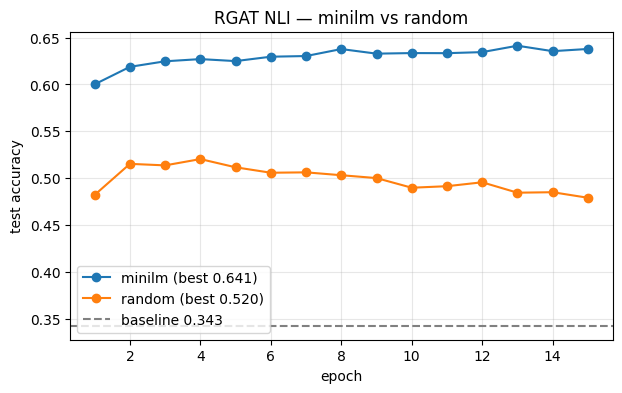

In [8]:
def acc_curve(res):
    return [h[0] for h in res["history"]], [h[2] for h in res["history"]]

plt.figure(figsize=(7, 4))
for res, lbl in [(res_minilm, "minilm"), (res_random, "random")]:
    ep, acc = acc_curve(res)
    plt.plot(ep, acc, marker="o", label=f"{lbl} (best {res['best_acc']:.3f})")
plt.axhline(res_minilm["baseline"], ls="--", c="gray", label=f"baseline {res_minilm['baseline']:.3f}")
plt.xlabel("epoch"); plt.ylabel("test accuracy"); plt.legend(); plt.grid(alpha=0.3)
plt.title("RGAT NLI — minilm vs random"); plt.show()

## Matrices de confusion

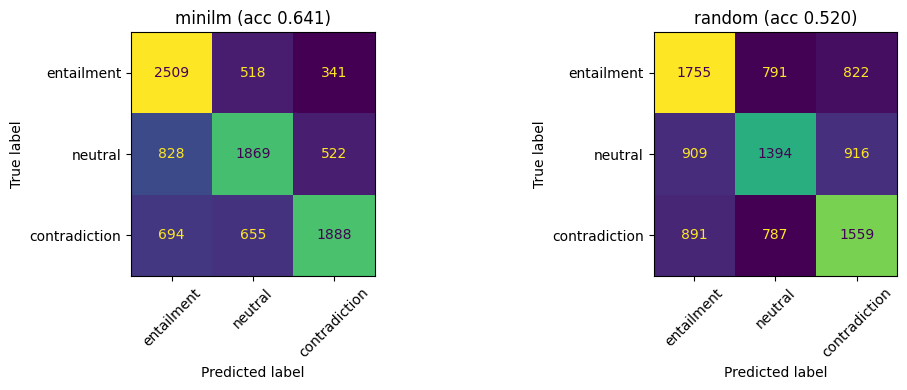

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, res, lbl in [(axes[0], res_minilm, "minilm"), (axes[1], res_random, "random")]:
    ConfusionMatrixDisplay(res["confusion"], display_labels=res["labels"]).plot(
        ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(f"{lbl} (acc {res['best_acc']:.3f})")
plt.tight_layout(); plt.show()

## Tableau récapitulatif

In [10]:
print(f"{'variante':<10} {'best acc':>10} {'final F1':>10}")
for res, lbl in [(res_minilm, "minilm"), (res_random, "random")]:
    print(f"{lbl:<10} {res['best_acc']:>10.3f} {res['history'][-1][3]:>10.3f}")
print(f"{'baseline':<10} {res_minilm['baseline']:>10.3f}")

variante     best acc   final F1
minilm          0.641      0.635
random          0.520      0.478
baseline        0.343
